# Data Understanding & Exploration

## Objective
- Understand structure of both orders and clicks dataset
- Identify key variables for analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Tahoma'

## 1. Load data

In [3]:
orders = pd.read_csv("../data/raw/orders_report_Mar_2026.csv", encoding='utf-8-sig')
clicks = pd.read_csv("../data/raw/clicks_report_Mar_2026.csv", encoding='utf-8-sig')

## 2. Preview Data

In [5]:
orders.iloc[20:26]

,รหัสการสั่งซื้อ,สถานะการสั่งซื้อ,เลขที่คำสั่งซื้อ,เวลาที่สั่งซื้อ,เวลาที่สั่งซื้อสำเร็จ,เวลาคลิก,ชื่อร้านค้า,ID ร้านค้า,ประเภทของร้านค้า,รหัสรายการสินค้า,...,สถานะสินค้า Affiliate,หมายเหตุสินค้า,ประเภทการแจกจ่าย,สถานะของผู้ซื้อ,Sub_id1,Sub_id2,Sub_id3,Sub_id4,Sub_id5,ช่องทาง
20,2774939412270535618,สำเร็จ,2774939412270535618,2026-03-31 13:43:33,2026-04-01 07:54:47,2026-03-28 10:10:42,Digital_byshopeeofficial,175825579,Shopee Mall(Non-CB),112765,...,สำเร็จ,NaN,คำสั่งซื้อจากร้านค้าต่างกัน,ที่มีอยู่,oppo,purple,NaN,NaN,NaN,Facebook
21,260331JJ9DYFSR,รอดำเนินการ,228638120296204,2026-03-31 13:35:40,NaN,2026-03-30 13:39:32,luck cherry,1374142779,C2C(Non-CB),25238428508,...,รอดำเนินการ,สถานะของสินค้านี้คือ อยู่ระหว่างดำเนินการ คอมม...,คำสั่งซื้อจากร้านค้าต่างกัน,ที่มีอยู่,judydoll,purple,NaN,NaN,NaN,Facebook
22,260331JEKNY6C6,รอดำเนินการ,228634168256082,2026-03-31 12:29:28,NaN,2026-03-26 23:48:53,ตี๋น้อย ไอ.ที.2020,315713905,Preferred(Non-CB),20312413543,...,รอดำเนินการ,สถานะของสินค้านี้คือ อยู่ระหว่างดำเนินการ คอมม...,คำสั่งซื้อจากร้านค้าต่างกัน,ที่มีอยู่,colgateOpticWhite,purple,NaN,NaN,NaN,Facebook
23,260331JD5U6N5C,รอดำเนินการ,228632630238884,2026-03-31 12:03:50,NaN,2026-03-30 13:39:58,imthip Korea.,56662754,C2C(Non-CB),28780875917,...,รอดำเนินการ,สถานะของสินค้านี้คือ อยู่ระหว่างดำเนินการ คอมม...,คำสั่งซื้อจากร้านค้าต่างกัน,ที่มีอยู่,judydoll,purple,NaN,NaN,NaN,Facebook
24,260331JBXUSSFE,รอดำเนินการ,228631322247142,2026-03-31 11:42:06,NaN,2026-03-30 23:38:05,Baby Hero Shop,423244626,C2C(Non-CB),41056850730,...,รอดำเนินการ,สถานะของสินค้านี้คือ อยู่ระหว่างดำเนินการ คอมม...,คำสั่งซื้อจากร้านค้าต่างกัน,ที่มีอยู่,oppo,white,NaN,NaN,NaN,Facebook
25,260331J8E6X2PU,รอดำเนินการ,228627542268338,2026-03-31 10:39:02,NaN,2026-03-28 23:58:25,okeyi,1376819489,C2C(Non-CB),25395667818,...,รอดำเนินการ,สถานะของสินค้านี้คือ อยู่ระหว่างดำเนินการ คอมม...,คำสั่งซื้อจากร้านค้าต่างกัน,ที่มีอยู่,nude,white,NaN,NaN,NaN,Others


In [6]:
clicks.iloc[20:26]

,รหัสคลิก,เวลาคลิก,ภาคที่คลิก,Sub_id,อ้างอิง
20,5a59991ff92156cfaea1a7a9461e68b4,2026-03-01 01:30:00,Thailand,----,Others
21,18f659dda536ad439c8738f1823510bb,2026-03-01 01:42:00,Thailand,----,Others
22,941c0258359fd97efe9dd4f2d7b99e7f,2026-03-01 01:57:00,Thailand,nude----,Facebook
23,5260e885544b476264309d7da2c1e2a2,2026-03-01 02:23:00,Thailand,judydoll-purple----,Facebook
24,1e72a2376981a1c16552a2f962006b85,2026-03-01 02:23:00,Thailand,judydoll-purple----,Facebook
25,43c8ad5ad05fcaf1ef61b40c89b972c2,2026-03-01 02:33:00,Thailand,aircandy----,Others


**Insights**  
Sub_id ถูกทำให้อยู่ในรูปแบบ ชื่อสินค้า-ชื่อกลุ่ม---- ดังนั้นต้องแยกเป็น  product และ group ในขั้นตอนถัดไป

## 3. Info / Shape

In [7]:
print("Orders shape:", orders.shape)
print("Clicks shape:", clicks.shape)

orders.info()
clicks.info()

Orders shape: (1450, 47)
Clicks shape: (8969, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   รหัสการสั่งซื้อ                            1450 non-null   object 
 1   สถานะการสั่งซื้อ                           1450 non-null   object 
 2   เลขที่คำสั่งซื้อ                           1450 non-null   int64  
 3   เวลาที่สั่งซื้อ                            1450 non-null   object 
 4   เวลาที่สั่งซื้อสำเร็จ                      1251 non-null   object 
 5   เวลาคลิก                                   1450 non-null   object 
 6   ชื่อร้านค้า                                1450 non-null   object 
 7   ID ร้านค้า                                 1450 non-null   int64  
 8   ประเภทของร้านค้า                           1450 non-null   object 
 9   รหัสรายการสินค้า                           1450

**Insights**   
- orders มี 47 columns ซึ่งค่อนข้างซับซ้อนเเต่ก็มีบาง column ที่ไม่มีค่าและไม่จำเป็นต้องใช้
- clicks มีเพียง 5 columns ดังนั้นจึงใช้เป็น supporting data

## 4. Feature Understanding

### Orders Dataset
1. **Sub_id1** = ชื่อสินค้าที่ตั้งใจ promote ในโพสต์นั้น   
    - ใช้ track ว่าสินค้าไหนที่ผู้คนให้ความสนใจเเละอยากสั่งซื้อ
2. **Sub_id2** = กลุ่ม Facebook (Marketing Channel)   
    - ใช้เพื่อวิเคราะห์ว่ากลุ่มไหนสร้าง order ได้มากที่สุด / ผู้คนคลิก link มากสุด
3. **ชื่อรายการสินค้า** = สินค้าที่ลูกค้าซื้อจริงๆจากการคลิก Link ในโพสต์นั้น
    - ใช้ดูพฤติกรรมการซื้อจริงของลูกค้า
4. **ค่าคอมมิชชั่นสุทธิ(฿)** = รายได้
    - KPI หลักของโปรเจคนี้
5. **ราคา(฿)** = ราคาสินค้า
    - ใช้วิเคราะห์ความสัมพันธ์กับค่า commission

### Clicks Dataset
1. **เวลาคลิก** = เวลาที่ผู้คนคลิกลิงก์   
    - ใช้วิเคราะห์พฤติกรรมผู้คน
3. **Sub_id** = product + group
    - ใช้ track ว่าคลิกมาจากสินค้าและกลุ่มไหน
4. **อ้างอิง** = source ของการ click
   - ใช้ดูว่าการคลิกมาจากการโพสต์ promote สินค้าผ่าน Facebook หรือการทำ shopee video

## 5. Data Quality Check

### 5.1 Missing Value

**Missing Values — Orders Dataset**

In [8]:
orders.isnull().sum()[orders.isnull().sum() > 0].sort_values(ascending=False)

พาร์ทเนอร์ในแคมเปญ       1450
Sub_id4                  1450
Sub_id5                  1450
ชื่อ MCN ที่ผูกไว้       1450
Sub_id3                  1450
เลขที่โปรโมชั่น          1378
จำนวนเงินคืน(฿)          1349
หมายเหตุสินค้า           1150
Sub_id2                   348
Sub_id1                   302
เวลาที่สั่งซื้อสำเร็จ     199
L3 หมวดหมู่สากล           120
dtype: int64

**Insights**   
- Sub_id1-2 ไม่มีข้อมูลบางส่วนเพราะ order อาจมาจาก shopee video หรือช่องทางอื่นที่ไม่ใช่จากการโพสต์ใน Facebook group ก็ได้
- Sub_id3-5 ไม่มีข้อมูลเพราะตอนสร้าง link เราไม่ได้ติด Sub_id 3-5
- ชื่อ MCN ไม่มีข้อมูล เพราะเราทำ Shopee Affiliate แบบไม่ได้มีชื่อสังกัดหรือบริษัทตัวกลางที่ทำสัญญาด้วยเพื่อช่วยดูแลการจัดการ content และค่า commission

**Missing Values — Clicks Dataset**

In [9]:
clicks.isnull().sum()[clicks.isnull().sum() > 0]

Sub_id    2080
dtype: int64

**Insights**   
สำหรับ dataset clicks มีเพียง column เดียวที่มี missing value คือ Sub_id เพราะ click บางส่วนอาจมาจาก shopee video หรือช่องทางอื่นที่ไม่ใช่จากการโพสต์ใน Facebook group ก็ได้

### 5.2 Duplicate Check

In [10]:
print("Orders duplicate:", orders.duplicated().sum())
print("Clicks duplicate:", clicks.duplicated().sum())

Orders duplicate: 0
Clicks duplicate: 0


**Insights**   
ไม่มี records ไหนใน dataset ที่ซ้ำกันเลย

### 5.3 Data Type Issues

In [11]:
orders.dtypes

รหัสการสั่งซื้อ                               object
สถานะการสั่งซื้อ                              object
เลขที่คำสั่งซื้อ                               int64
เวลาที่สั่งซื้อ                               object
เวลาที่สั่งซื้อสำเร็จ                         object
เวลาคลิก                                      object
ชื่อร้านค้า                                   object
ID ร้านค้า                                     int64
ประเภทของร้านค้า                              object
รหัสรายการสินค้า                               int64
ชื่อรายการสินค้า                              object
เลขที่ โมเดล                                   int64
ประเภทสินค้า                                  object
เลขที่โปรโมชั่น                               object
L1 หมวดหมู่สากล                               object
L2 หมวดหมู่สากล                               object
L3 หมวดหมู่สากล                               object
ราคา(฿)                                      float64
จำนวน                                         

**Insights**   
column ที่เกี่ยวกับเวลา(เวลาที่สั่งซื้อ, เวลาที่สั่งซื้อสำเร็จ, เวลาคลิก) ยังคงเป็น object (string) อยู่ ดังนั้นต้องแปลงเป็น datetime เพื่อนำไปวิเคราะห์ต่อ

In [12]:
clicks.dtypes

รหัสคลิก      object
เวลาคลิก      object
ภาคที่คลิก    object
Sub_id        object
อ้างอิง       object
dtype: object

**Insights**   
column ที่เกี่ยวกับเวลา(เวลาคลิก) ยังคงเป็น object (string) อยู่ ดังนั้นต้องแปลงเป็น datetime เพื่อนำไปวิเคราะห์ต่อ

## 6. Statistical Summary

### 6.1 Numerical Distribution

**Basic statistics of numerical features**

In [13]:
orders[['ราคา(฿)', 'จำนวน', 'มูลค่าซื้อ(฿)', 'ค่าคอมมิชชั่นสุทธิ(฿)']].describe()

,ราคา(฿),จำนวน,มูลค่าซื้อ(฿),ค่าคอมมิชชั่นสุทธิ(฿)
count,1450.000000,1450.000000,1450.000000,1450.000000
mean,277.177609,1.253793,216.871131,5.181906
std,819.062528,1.217144,632.377255,15.069425
min,0.000000,0.000000,0.000000,0.000000
25%,40.000000,1.000000,30.250000,0.000000
50%,109.000000,1.000000,94.000000,0.511250
75%,275.000000,1.000000,223.750000,3.423750
max,17990.000000,20.000000,15706.000000,225.000000


**Insights**   
- **ราคา** มีลักษณะเป็น right-skewed (mean > median) แสดงว่ามีสินค้าราคาสูงบางรายการที่ดึงค่าเฉลี่ยให้สูงขึ้น
- **จำนวน** ส่วนใหญ่เป็น 1 แสดงว่าผู้ซื้อส่วนใหญ่มักสั่งซื้อสินค้าเพียงชิ้นเดียวต่อคำสั่งซื้อ
- **มูลค่าซื้อ (GMV)** มีค่าเฉลี่ยต่ำกว่าราคา อาจเป็นเพราะส่วนลดหรือคำสั่งซื้อที่มีมูลค่าเป็น 0
- **ค่าคอมมิชชั่นสุทธิ** มีการกระจายแบบ skewed และมี long tail แสดงว่ารายได้ส่วนใหญ่มาจากคำสั่งซื้อจำนวนนึงที่มีมูลค่าสูง

**Commission Distribution and Outlier Detection (IQR Method)**

In [14]:
Q1 = orders['ค่าคอมมิชชั่นสุทธิ(฿)'].quantile(0.25)
Q3 = orders['ค่าคอมมิชชั่นสุทธิ(฿)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -5.135625
Upper bound: 8.559375


In [15]:
outliers = orders[
    (orders['ค่าคอมมิชชั่นสุทธิ(฿)'] < lower_bound) |
    (orders['ค่าคอมมิชชั่นสุทธิ(฿)'] > upper_bound)
]
outliers[['รหัสการสั่งซื้อ', 'ชื่อรายการสินค้า', 'ราคา(฿)', 'ค่าคอมมิชชั่นสุทธิ(฿)']].sort_values(by='ค่าคอมมิชชั่นสุทธิ(฿)')

,รหัสการสั่งซื้อ,ชื่อรายการสินค้า,ราคา(฿),ค่าคอมมิชชั่นสุทธิ(฿)
393,260323TS18J4VN,กันแดด โทนอัพ | ยูเซอริน Eucerin Sun Protectio...,548.0,8.6275
355,260324VJV99C4U,เซราวี CERAVE Facial Moisturising Lotion เฟเชี...,620.0,8.6800
1322,2603048H7BAH6S,LA GLACE FIERY BABY-DOLLY EYE STICK | ปากกาดอล...,199.0,8.7500
990,260310QDDQ97C2,ชุดนอนเซ็กซี่ ชุดนอนไม่ได้นอน 🎗️ ป้าย รุ่นD70...,112.0,8.7550
1090,260308KUAD0GXU,CryingCenter เสื้อยืดเบบี้ทีคอกลม Baby Tee Spi...,769.0,8.7600
...,...,...,...,...
206,2603289KV1WU1T,ถ้วยอนามัย FlowDays SizeA Light flow 5 สี เลือ...,1100.0,113.8500
210,2603279FEWACYE,ถ้วยอนามัย FlowDays SizeA Light flow 5 สี เลือ...,1100.0,113.8500
128,260329DEFE97F8,[New] Xiaomi POCO X8 Pro 8+256/8+512/12+512 ชิ...,13999.0,154.4850
1071,260309MKSBYCB7,"Align pilates Pro Pilates Ring 14"" พิลาทิสริง ...",2450.0,205.4325


In [16]:
print("Number of outliers:", len(outliers))
print("Percentage:", len(outliers) / len(orders) * 100)
orders['ค่าคอมมิชชั่นสุทธิ(฿)'].describe()

Number of outliers: 214
Percentage: 14.758620689655173


count    1450.000000
mean        5.181906
std        15.069425
min         0.000000
25%         0.000000
50%         0.511250
75%         3.423750
max       225.000000
Name: ค่าคอมมิชชั่นสุทธิ(฿), dtype: float64

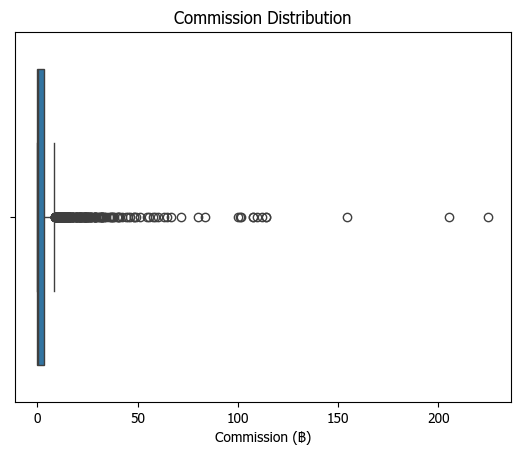

In [17]:
sns.boxplot(x=orders['ค่าคอมมิชชั่นสุทธิ(฿)'])

plt.title('Commission Distribution')
plt.xlabel('Commission (฿)')

plt.show()

**Insights**   
- พบว่าค่า commission ส่วนใหญ่กระจุกอยู่ในช่วงที่ต่ำมาก แสดงให้เห็นว่า orders ส่วนใหญ่มักสร้างรายได้ในระดับต่ำ
- พบว่าค่า commission มี outliers ที่สูงผิดปกติจำนวน 214 รายการ (14.76% ของข้อมูล) โดยค่าสูงสุดอยู่ที่ประมาณ 225 บาท ในขณะที่ median อยู่ที่ 0.51 บาท
- Outliers เกิดจากสินค้าที่ราคาสูงเช่น 10,000+ บาท หรือสินค้าที่มี commission rate สูง 
- มี distribution เป็น right-skewed เนื่องจาก mean สูงกว่า median อย่างมาก   

**Business Impact**   
แสดงว่ารายได้ไม่ได้กระจายเท่ากันทุก order เเต่มันพึ่งพา order ทีมีค่า commission สูงที่มีเพียงไม่กี่รายการ ดังนั้นไม่ควร clean outliers ออกจาก dataset เพราะมันเป็นพฤติกรรมจริงของผู้ซื้อ และมีผลต่อรายได้จริง

### 6.2 Categorical Distribution

**6.2.1 Orders by Facebook Group**

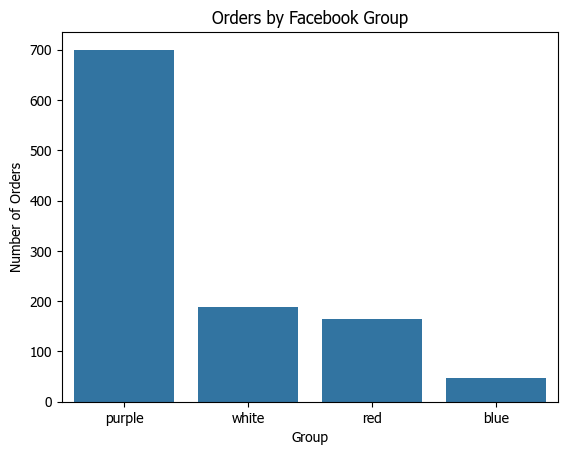

In [18]:
sns.countplot(data=orders, x='Sub_id2')

plt.title('Orders by Facebook Group')
plt.xlabel('Group')
plt.ylabel('Number of Orders')
plt.show()

**Insights**   
พบว่า orders ส่วนใหญ่มาจากกลุ่ม Facebook purple (ของดีต้องแชร์ Shopee / Lazada) ส่วน group อื่นๆ มีจำนวน orders น้อยกว่ามาก ซึ่งอาจเกิดจาก engagement สูงกว่าหรือกลุ่ม target ตรงกว่า

**Business Impact**    
เราควร focus resource (เวลา / content) ไปที่กลุ่ม purple ส่วนกลุ่มอื่นๆเราอาจต้องปรับ strategy ในการขายใหม่

**6.2.2 Top 5 Promoted Products by Orders**

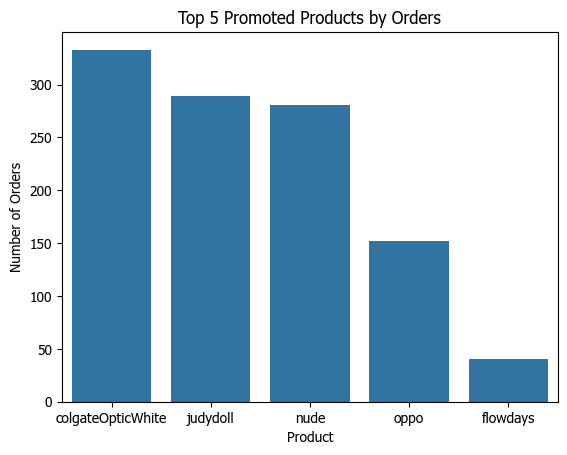

In [19]:
top_products = orders['Sub_id1'].value_counts().head(5)
sns.barplot(x=top_products.index, y=top_products.values)

plt.title('Top 5 Promoted Products by Orders')
plt.xlabel('Product')
plt.ylabel('Number of Orders')

plt.show()

**Insights**   
demand กระจุกตัวอยู่ในสินค้าบางกลุ่มอย่าง ยาสีฟัน colgateOpticWhite, พาเลตไฮไลต์คอนทัวร์ judydoll, ลูกอม nude, มือถือ oppo A6 PRO 5G ซึ่งมีจำนวน orders สูงกว่าสินค้าอื่นอย่างชัดเจน   

**Business Impact**   
แสดงว่าผู้คนสนใจใน content ที่เราทำเพื่อ promote สินค้าเหล่านี้ซึ่งหมายความว่าสินค้ามีความน่าสนใจ / มีแนวโน้มที่จะแก้ pain point ของผู้คนส่วนใหญ่ได้ จึงคลิก link เข้าไปดูสินค้าเหล่านี้

**6.2.3 Top 5 Purchased Products (Actual Customer Purchases)**

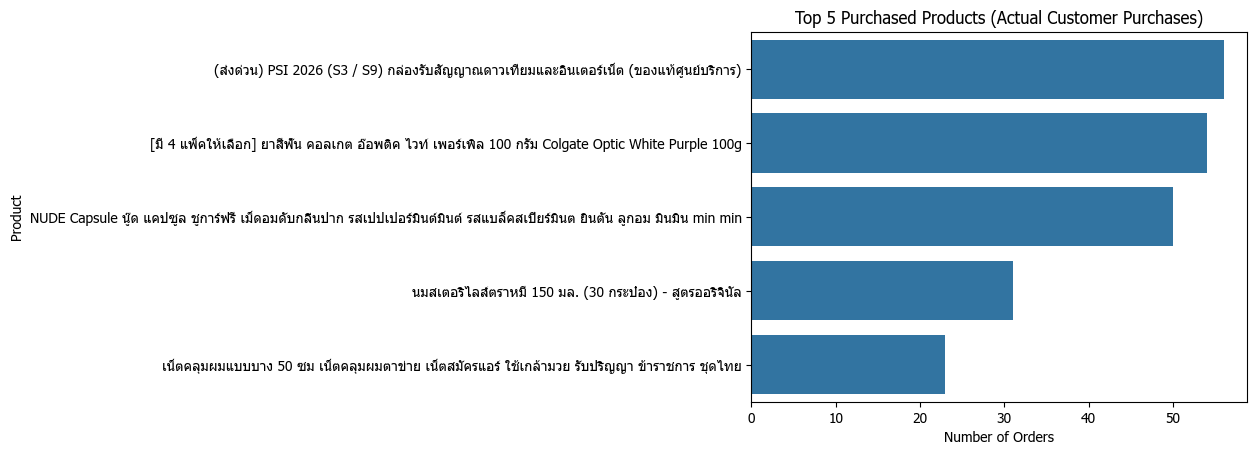

In [20]:
top_products = orders['ชื่อรายการสินค้า'].value_counts().head(5)
sns.barplot(x=top_products.values, y=top_products.index)

plt.title('Top 5 Purchased Products (Actual Customer Purchases)')
plt.xlabel('Number of Orders')
plt.ylabel('Product')
plt.show()

**Insights**  
สิ่งนี้แสดงให้เห็นถึงความนิยมในกลุ่มผู้ซื้อ ซึ่งก็พบว่ามีสินค้าที่เราตั้งใจ Promoted อย่าง ยาสีฟัน Colgate Optic White และ ลูกอม Nude ก็ติดอันดับด้วยแสดงให้เห็นว่าผู้คนสั่งซื้อสินค้าจากความน่าสนใจของ content ด้วยเช่นกัน
อย่างไรก็ตามสินค้าบางตัวที่เห็นว่าขายได้จำนวนเยอะ อาจจะมาจากการสั่งซื้อ 1 ครั้งของลูกค้าคนเดียวก็ได้ ดังนั้นเราอาจต้องดู column "จำนวน" ประกอบด้วยเพื่อจะได้รู้ว่าสินค้าที่ผู้คนหลายๆคนนิยมซื้อคืออะไร

**Business Impact**   
วิธีการนำเสนอ content ของสินค้าที่ promote มีอิทธิพลต่อพฤติกรรมการซื้อจริงของผู้คน เเต่ก็ไม่เสมอไปเพราะบางทีผู้ซื้อคลิก link สินค้าเเล้วก็อาจไปซื้อสินค้าชนิดอื่นซึ่งนี่ก็เป็นโอกาสที่ทำให้เราเห็นว่าเราควรลองหาสินค้าใหม่ที่มี demand สูงมาลองโพสต์ promote ดูบ้าง

**6.2.4 Top 5 Products with Group by Number of Clicks**

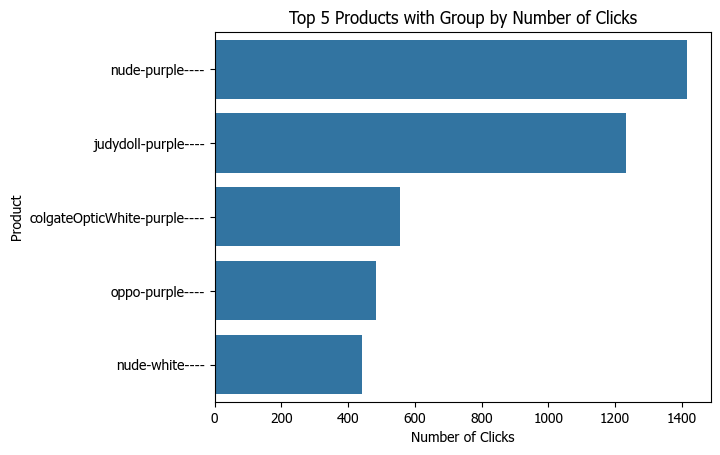

In [21]:
top_products = clicks['Sub_id'].value_counts().head(5)
sns.barplot(x=top_products.values, y=top_products.index)

plt.title('Top 5 Products with Group by Number of Clicks')
plt.xlabel('Number of Clicks')
plt.ylabel('Product')

plt.show()

**Insights**   
clicks ส่วนใหญ่มากจากกลุ่ม Facebook purple ซึ่งสอดคล้องกับกราฟก่อนหน้านี้ที่เเสดงให้เห็นว่า order ส่วนใหญ่มาจากกลุ่ม purple   
ส่วน product ที่ผู้คน click ก็สอดคล้องกับกราฟก่อนหน้านี้ที่เเสดงให้เห็นว่า orders ส่วนใหญ่มาจาก product เหล่านี้   
ดังนั้น high clicks อาจนำไปสู่ high orders

**Business Impact**   
กลุ่ม purple ไม่ได้เเค่สร้าง traffic สูง เเต่ยังสามารถ convert เป็น orders ได้ดีด้วย

**6.2.5 Order Status Distribution**

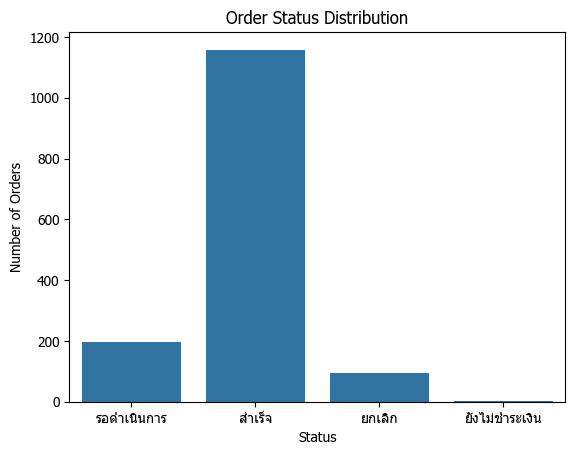

In [22]:
sns.countplot(data=orders, x='สถานะการสั่งซื้อ')

plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.show()

**Insights**   
order ส่วนใหญ่อยู่ในสถานะสำเร็จคือผู้ซื้อได้รับของเรียบร้อยเเล้ว

## 7. Association Analysis
**Objetive :** เพื่อวิเคราะห์ความสัมพันธ์ระหว่างตัวแปรสำคัญที่อาจมีผลต่อรายได้ (commission)

**7.1 Price vs Commission**   
    Hypothesis : สินค้าที่มีราคาสูงขึ้นจะสร้างค่า commission สูงขึ้น

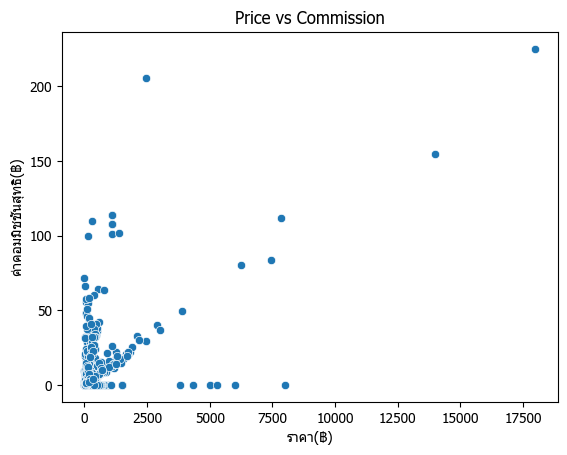

np.float64(0.5597504214699502)

In [23]:
sns.scatterplot(
    data=orders,
    x='ราคา(฿)',
    y='ค่าคอมมิชชั่นสุทธิ(฿)'
)

plt.title('Price vs Commission')
plt.show()

orders['ราคา(฿)'].corr(orders['ค่าคอมมิชชั่นสุทธิ(฿)'])

**Insights**   
"ราคา" และ "ค่าคอมมิชชัน" มีความสัมพันธ์แบบ moderate positive relationship คือไปในทิศทางเดียวกันโดยราคาสินค้าที่สูงขึ้นจะส่งผลให้ค่า commission สูงขึ้นโดยรวม แต่มีความแน่นอนเพียงระดับปานกลางเท่านั้นเพราะอาจมีปัจจัยอื่นเข้ามาเกี่ยวข้องอย่างประเภทสินค้า หรือ promotion

**7.2 Commission by Facebook Group**  
Hypothesis : บาง Facebook group อาจมี performance ที่ดีกว่ากลุ่มอื่นในการสร้างรายได้

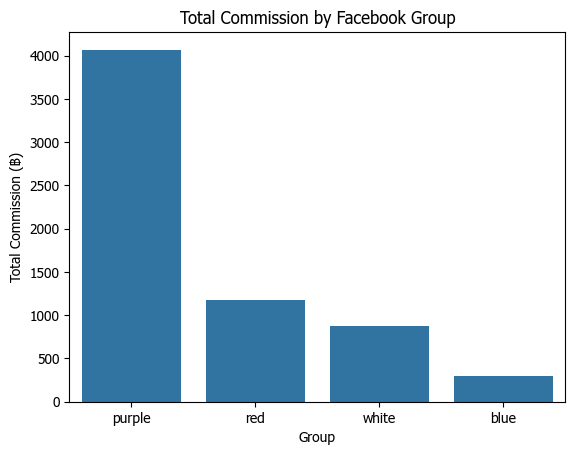

In [24]:
group_commission = orders.groupby('Sub_id2')['ค่าคอมมิชชั่นสุทธิ(฿)'].sum().sort_values(ascending=False)

sns.barplot(x=group_commission.index, y=group_commission.values)

plt.title('Total Commission by Facebook Group')
plt.xlabel('Group')
plt.ylabel('Total Commission (฿)')
plt.show()

**Insights**   
กลุ่ม Facebook purple สร้าง commission ได้สูงสุด ซึ่งมีความสอดคล้องกับก่อนหน้านี้ที่เราทาราบว่า orders เเละ clicks ส่วนใหญ่มาจากกลุ่มนี้

# Summary & Key Findings

## Data Quality Issues
**ต้องจัดการในขั้นตอนต่อไป (Data Cleaning & Preparation)**
- ทั้ง 2 dataset ต้องมีการแปลง column เวลาทุกอัน (เวลาที่สั่งซื้อ, เวลาที่สั่งซื้อสำเร็จ, เวลาคลิก) เป็น data type datetime
- Sub_id ใน clicks อยู่ในรูป "product-group----" ต้องแยกออกเป็น 2 columns คือ product และ group
- ต้อง Drop Column ที่ไม่จำเป็นซึ่งค่อนข้างมีหลาย column

## Key Findings   
- Commission distribution เป็น right-skewed มี
  median เพียง 0.51 บาท, mean 5.18 บาท
  แสดงว่ารายได้พึ่งพา high-value orders ไม่กี่รายการ
- กลุ่ม Facebook purple (ของดีต้องแชร์ Shopee / Lazada) สร้าง commission สูงสุด และมี clicks และ orders มากที่สุดด้วย